## **DATA CLEANING **

In [ ]:
import pandas as pd
import pandas as pd
import numpy as np

df = pd.read_excel("/content/SEER Breast Cancer Dataset  (1).xlsx")

df.head()

df = pd.read_excel("/content/SEER Breast Cancer Dataset  (1).xlsx")

df.head()


,Age,Race,Marital Status,T Stage,N Stage,6th Stage,Grade,A Stage,Tumor Size,Estrogen Status,Progesterone Status,Regional Node Examined,Reginol Node Positive,Survival Months,Status
0,43,Other,Married (including common law),T2,N3,IIIC,Moderately differentiated; Grade II,Regional,40,Positive,Positive,19,11,1,Alive
1,47,Other,Married (including common law),T2,N2,IIIA,Moderately differentiated; Grade II,Regional,45,Positive,Positive,25,9,2,Alive
2,67,White,Married (including common law),T2,N1,IIB,Poorly differentiated; Grade III,Regional,25,Positive,Positive,4,1,2,Dead
3,46,White,Divorced,T1,N1,IIA,Moderately differentiated; Grade II,Regional,19,Positive,Positive,26,1,2,Dead
4,63,White,Married (including common law),T2,N2,IIIA,Moderately differentiated; Grade II,Regional,35,Positive,Positive,21,5,3,Dead


In [ ]:
print("Dataset Shape (Rows, Columns):", df.shape)


Dataset Shape (Rows, Columns): (4024, 15)


In [ ]:
print("Total Columns:", len(df.columns))
print("\nColumn Names:\n")
for col in df.columns:
    print(col)


Total Columns: 15

Column Names:

Age
Race 
Marital Status
T Stage 
N Stage
6th Stage
Grade
A Stage
Tumor Size
Estrogen Status
Progesterone Status
Regional Node Examined
Reginol Node Positive
Survival Months
Status


In [ ]:
df = df.drop(columns=['Marital Status'])

print("Marital Status column removed.")
print("Updated shape:", df.shape)


Marital Status column removed.
Updated shape: (4024, 14)


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4024 entries, 0 to 4023
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Age                     4024 non-null   int64 
 1   Race                    4024 non-null   object
 2   T Stage                 4024 non-null   object
 3   N Stage                 4024 non-null   object
 4   6th Stage               4024 non-null   object
 5   Grade                   4024 non-null   object
 6   A Stage                 4024 non-null   object
 7   Tumor Size              4024 non-null   int64 
 8   Estrogen Status         4024 non-null   object
 9   Progesterone Status     4024 non-null   object
 10  Regional Node Examined  4024 non-null   int64 
 11  Reginol Node Positive   4024 non-null   int64 
 12  Survival Months         4024 non-null   int64 
 13  Status                  4024 non-null   object
dtypes: int64(5), object(9)
memory usage: 440.3+ KB


In [ ]:
unique_counts = df.nunique().sort_values(ascending=False)

print("\nUnique Values in Each Column:\n")
print(unique_counts)



Unique Values in Each Column:

Tumor Size                110
Survival Months           107
Regional Node Examined     54
Age                        40
Reginol Node Positive      38
6th Stage                   5
T Stage                     4
Grade                       4
N Stage                     3
Race                        3
Progesterone Status         2
Estrogen Status             2
A Stage                     2
Status                      2
dtype: int64


In [ ]:
eda_summary = pd.DataFrame({
    "Data Type": df.dtypes,
    "Missing Values": df.isnull().sum(),
    "Missing (%)": (df.isnull().mean() * 100).round(2),
    "Unique Values": df.nunique()
})

eda_summary.to_csv("eda_summary.csv")


In [ ]:
df = df.dropna(axis=1, how='all')


In [ ]:
print("Duplicate rows before:", df.duplicated().sum())

df = df.drop_duplicates()

print("Duplicate rows after:", df.duplicated().sum())


Duplicate rows before: 1
Duplicate rows after: 0


In [ ]:
print(df.isnull().sum())


Age                       0
Race                      0
T Stage                   0
N Stage                   0
6th Stage                 0
Grade                     0
A Stage                   0
Tumor Size                0
Estrogen Status           0
Progesterone Status       0
Regional Node Examined    0
Reginol Node Positive     0
Survival Months           0
Status                    0
dtype: int64


In [ ]:
df['Status'] = df['Status'].map({'Alive': 0, 'Dead': 1})


In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

categorical_cols = df.select_dtypes(include='object').columns

print("Categorical Columns:\n", categorical_cols)

for col in categorical_cols:
    df[col] = label_encoder.fit_transform(df[col])


Categorical Columns:
 Index(['Race ', 'T Stage ', 'N Stage', '6th Stage', 'Grade', 'A Stage',
       'Estrogen Status', 'Progesterone Status'],
      dtype='object')


In [ ]:
print(df.dtypes)

print("Final Dataset Shape:", df.shape)

df.head()


Age                       int64
Race                      int64
T Stage                   int64
N Stage                   int64
6th Stage                 int64
Grade                     int64
A Stage                   int64
Tumor Size                int64
Estrogen Status           int64
Progesterone Status       int64
Regional Node Examined    int64
Reginol Node Positive     int64
Survival Months           int64
Status                    int64
dtype: object
Final Dataset Shape: (4023, 14)


,Age,Race,T Stage,N Stage,6th Stage,Grade,A Stage,Tumor Size,Estrogen Status,Progesterone Status,Regional Node Examined,Reginol Node Positive,Survival Months,Status
0,43,1,1,2,4,0,1,40,1,1,19,11,1,0
1,47,1,1,1,2,0,1,45,1,1,25,9,2,0
2,67,2,1,0,1,1,1,25,1,1,4,1,2,1
3,46,2,0,0,0,0,1,19,1,1,26,1,2,1
4,63,2,1,1,2,0,1,35,1,1,21,5,3,1


In [ ]:
df.to_csv("breast_cancer_survival_processed.csv", index=False)

print("Processed dataset saved successfully.")


Processed dataset saved successfully.


# **STATISTICAL ANALYSIS**

In [ ]:
stat_summary = df.describe().T
stat_summary


,count,mean,std,min,25%,50%,75%,max
Age,4023.0,53.969923,8.963118,30.0,47.0,54.0,61.0,69.0
Race,4023.0,1.775789,0.564524,0.0,2.0,2.0,2.0,2.0
T Stage,4023.0,0.784986,0.765526,0.0,0.0,1.0,1.0,3.0
N Stage,4023.0,0.438479,0.693531,0.0,0.0,0.0,1.0,2.0
6th Stage,4023.0,1.322148,1.266610,0.0,0.0,1.0,2.0,4.0
Grade,4023.0,0.690529,1.016486,0.0,0.0,0.0,1.0,3.0
A Stage,4023.0,0.977131,0.149503,0.0,1.0,1.0,1.0,1.0
Tumor Size,4023.0,30.477007,21.121253,1.0,16.0,25.0,38.0,140.0
Estrogen Status,4023.0,0.933134,0.249820,0.0,1.0,1.0,1.0,1.0
Progesterone Status,4023.0,0.826498,0.378728,0.0,1.0,1.0,1.0,1.0


In [ ]:
status_count = df['Status'].value_counts()
status_percentage = df['Status'].value_counts(normalize=True) * 100

print("Survival Status Count:\n", status_count)
print("\nSurvival Status Percentage:\n", status_percentage)


Survival Status Count:
 Status
0    3407
1     616
Name: count, dtype: int64

Survival Status Percentage:
 Status
0    84.688044
1    15.311956
Name: proportion, dtype: float64


In [ ]:
group_stats = df.groupby('Status').mean()
group_stats


,Age,Race,T Stage,N Stage,6th Stage,Grade,A Stage,Tumor Size,Estrogen Status,Progesterone Status,Regional Node Examined,Reginol Node Positive,Survival Months
Status,,,,,,,,,,,,,
0,53.756384,1.787790,0.734664,0.363076,1.183446,0.698562,0.983270,29.27238,0.952744,0.855004,14.238920,3.601409,75.946874
1,55.150974,1.709416,1.063312,0.855519,2.089286,0.646104,0.943182,37.13961,0.824675,0.668831,15.019481,7.241883,45.610390


In [ ]:
std_dev = df.std().sort_values(ascending=False)
std_dev


,0
Survival Months,22.923009
Tumor Size,21.121253
Age,8.963118
Regional Node Examined,8.100241
Reginol Node Positive,5.109724
6th Stage,1.266610
Grade,1.016486
T Stage,0.765526
N Stage,0.693531
Race,0.564524


# **DATA VISUALIZATION**

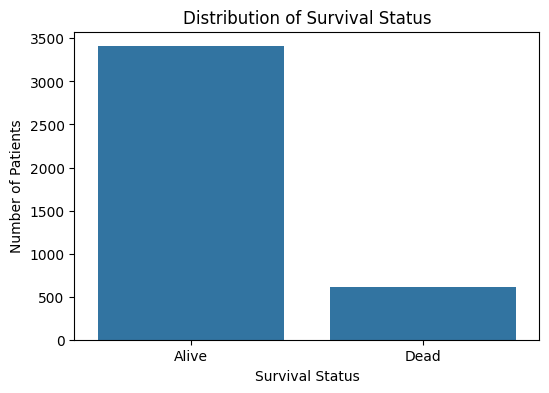

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x='Status', data=df)
plt.xticks([0,1], ['Alive', 'Dead'])
plt.xlabel("Survival Status")
plt.ylabel("Number of Patients")
plt.title("Distribution of Survival Status")
plt.show()


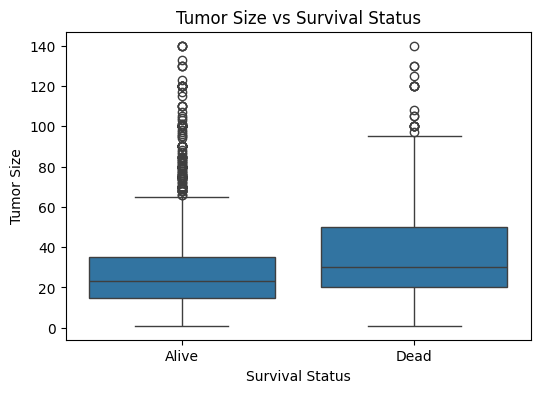

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Status', y='Tumor Size', data=df)
plt.xticks([0,1], ['Alive', 'Dead'])
plt.xlabel("Survival Status")
plt.ylabel("Tumor Size")
plt.title("Tumor Size vs Survival Status")
plt.show()


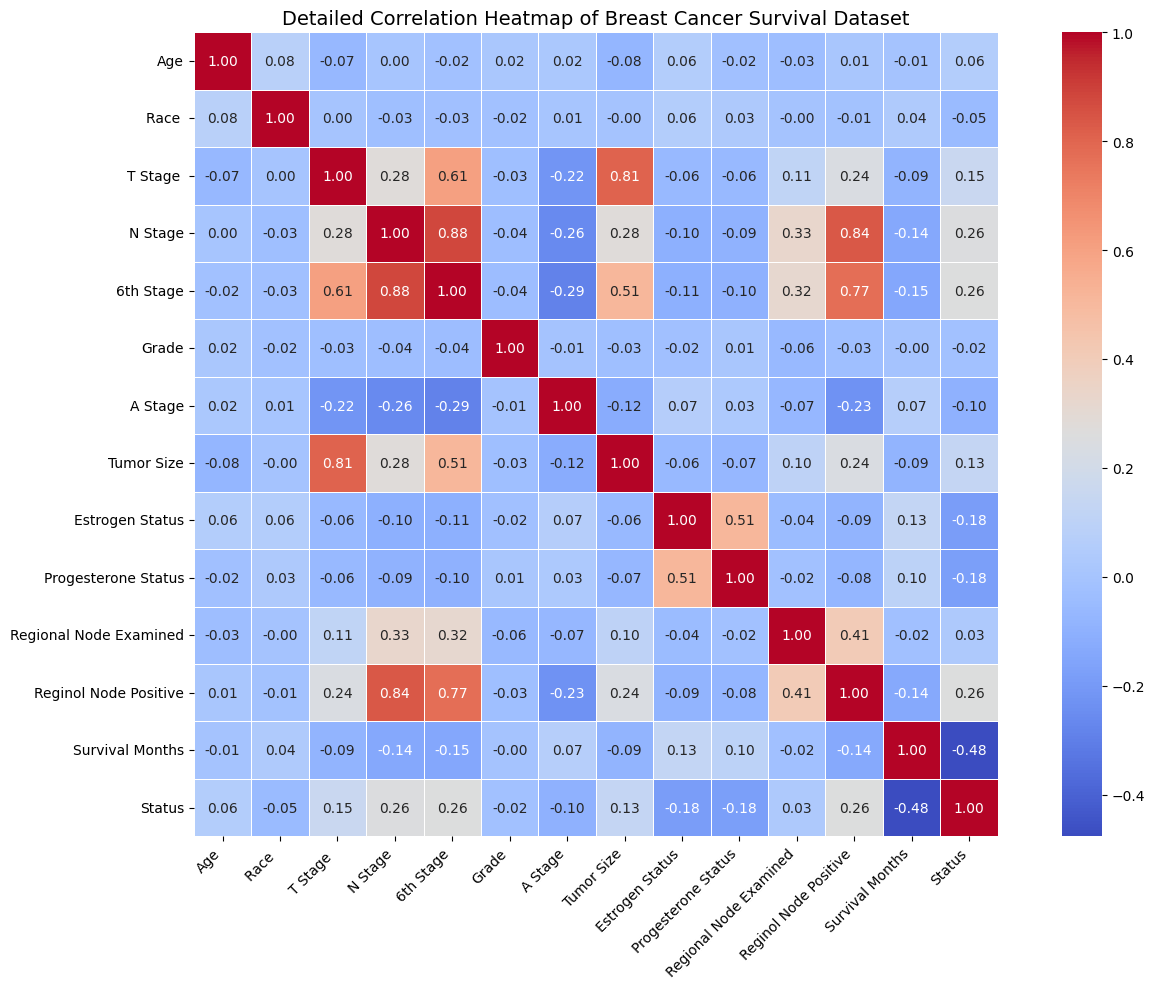

In [ ]:
plt.figure(figsize=(14,10))
corr = df.corr()
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    cbar=True,
    square=True
)

plt.title("Detailed Correlation Heatmap of Breast Cancer Survival Dataset", fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


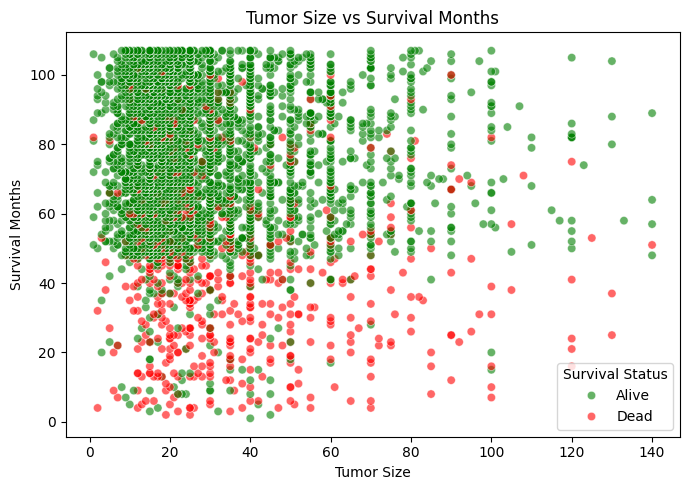

In [ ]:

df_plot = df.copy()
df_plot['Survival_Status'] = df_plot['Status'].map({0: 'Alive', 1: 'Dead'})

plt.figure(figsize=(7,5))

sns.scatterplot(
    x='Tumor Size',
    y='Survival Months',
    hue='Survival_Status',
    data=df_plot,
    palette={'Alive': 'green', 'Dead': 'red'},
    alpha=0.6
)

plt.title("Tumor Size vs Survival Months")
plt.xlabel("Tumor Size")
plt.ylabel("Survival Months")

plt.legend(title="Survival Status")
plt.tight_layout()
plt.show()


# **Mutual Information**
Mutual Information measures how much information a feature provides about the target variable by capturing both linear and non-linear dependencies.


In [ ]:
from sklearn.feature_selection import mutual_info_classif
X = df.drop('Status', axis=1)
y = df['Status']


In [ ]:

mi_scores = mutual_info_classif(
    X,
    y,
    random_state=42
)
mi_df = pd.DataFrame({
    'Feature': X.columns,
    'Mutual_Information': mi_scores
})

mi_df = mi_df.sort_values(by='Mutual_Information', ascending=False)

mi_df


,Feature,Mutual_Information
12,Survival Months,0.135601
4,6th Stage,0.028568
11,Reginol Node Positive,0.026312
3,N Stage,0.024957
6,A Stage,0.018348
0,Age,0.013367
9,Progesterone Status,0.011406
5,Grade,0.010069
7,Tumor Size,0.009843
8,Estrogen Status,0.008220


/tmp/ipython-input-3714324151.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


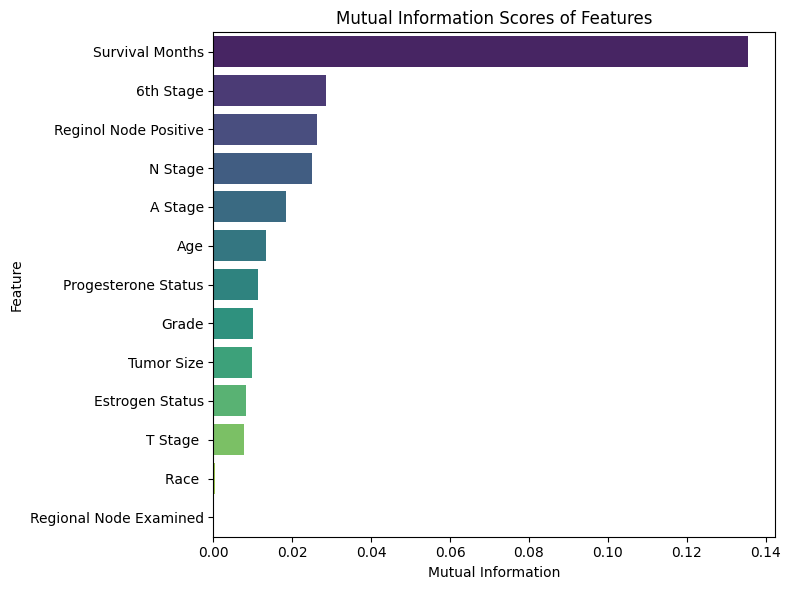

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.barplot(
    x='Mutual_Information',
    y='Feature',
    data=mi_df,
    palette='viridis'
)

plt.title("Mutual Information Scores of Features")
plt.xlabel("Mutual Information")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


In [ ]:
mi_threshold = 0.02

selected_features_mi = mi_df[
    mi_df['Mutual_Information'] >= mi_threshold
]['Feature'].tolist()

print("Selected Features based on Mutual Information:\n")
print(selected_features_mi)


Selected Features based on Mutual Information:

['Survival Months', '6th Stage', 'Reginol Node Positive', 'N Stage']


# **Stability Selection**
Stability selection identifies features that remain consistently important across multiple resampled versions of the dataset, ensuring robustness and reliability.


In [ ]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.utils import resample
import pandas as pd
import numpy as np


In [ ]:
X = df.drop('Status', axis=1)
y = df['Status']

n_iterations = 100
top_k = 5


In [ ]:
feature_frequency = {feature: 0 for feature in X.columns}

for i in range(n_iterations):

    X_sample, y_sample = resample(
        X, y,
        replace=True,
        random_state=i
    )

    mi_scores = mutual_info_classif(
        X_sample,
        y_sample,
        random_state=i
    )

    mi_temp = pd.DataFrame({
        'Feature': X.columns,
        'MI': mi_scores
    }).sort_values(by='MI', ascending=False)


    selected = mi_temp.head(top_k)['Feature']

    for feature in selected:
        feature_frequency[feature] += 1


In [ ]:
stability_df = pd.DataFrame({
    'Feature': feature_frequency.keys(),
    'Stability_Score': feature_frequency.values()
})


stability_df['Stability_Percentage'] = (
    stability_df['Stability_Score'] / n_iterations
) * 100


stability_df = stability_df.sort_values(
    by='Stability_Percentage',
    ascending=False
)

stability_df


,Feature,Stability_Score,Stability_Percentage
12,Survival Months,100,100.0
11,Reginol Node Positive,98,98.0
4,6th Stage,95,95.0
3,N Stage,95,95.0
7,Tumor Size,64,64.0
9,Progesterone Status,17,17.0
8,Estrogen Status,12,12.0
0,Age,7,7.0
2,T Stage,6,6.0
5,Grade,5,5.0


/tmp/ipython-input-535395089.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


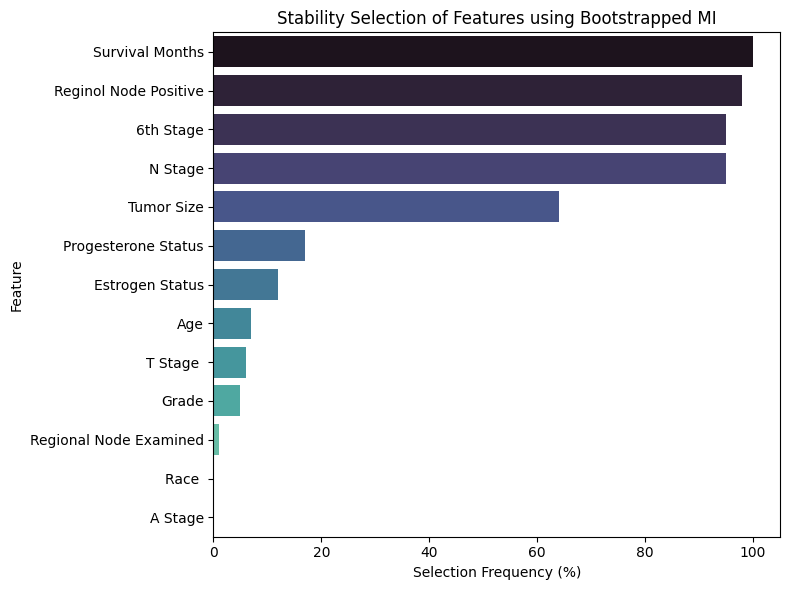

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.barplot(
    x='Stability_Percentage',
    y='Feature',
    data=stability_df,
    palette='mako'
)

plt.xlabel("Selection Frequency (%)")
plt.ylabel("Feature")
plt.title("Stability Selection of Features using Bootstrapped MI")
plt.tight_layout()
plt.show()


In [ ]:
stability_threshold = 60

stable_features = stability_df[
    stability_df['Stability_Percentage'] >= stability_threshold
]['Feature'].tolist()

print("Stable Features Selected:\n")
print(stable_features)


Stable Features Selected:

['Survival Months', 'Reginol Node Positive', '6th Stage', 'N Stage', 'Tumor Size']


In [ ]:
print(df.columns.tolist())


['Age', 'Race ', 'T Stage ', 'N Stage', '6th Stage', 'Grade', 'A Stage', 'Tumor Size', 'Estrogen Status', 'Progesterone Status', 'Regional Node Examined', 'Reginol Node Positive', 'Survival Months', 'Status']


# **Ethnicity**

In [ ]:
file_path = "/content/SEER Breast Cancer Dataset  (1).xlsx"
df = pd.read_excel(file_path)

df.columns = df.columns.str.strip()

In [ ]:
race_table = df['Race'].value_counts().reset_index()
race_table.columns = ['Ethnicity', 'Number of Patients']

race_table


,Ethnicity,Number of Patients
0,White,3413
1,Other,320
2,Black,291


Columns: ['Age', 'Race', 'Marital Status', 'T Stage', 'N Stage', '6th Stage', 'Grade', 'A Stage', 'Tumor Size', 'Estrogen Status', 'Progesterone Status', 'Regional Node Examined', 'Reginol Node Positive', 'Survival Months', 'Status']

Check Ethnicity & Status:
  Ethnicity Status
0     Other  Alive
1     Other  Alive
2     White   Dead
3     White   Dead
4     White   Dead


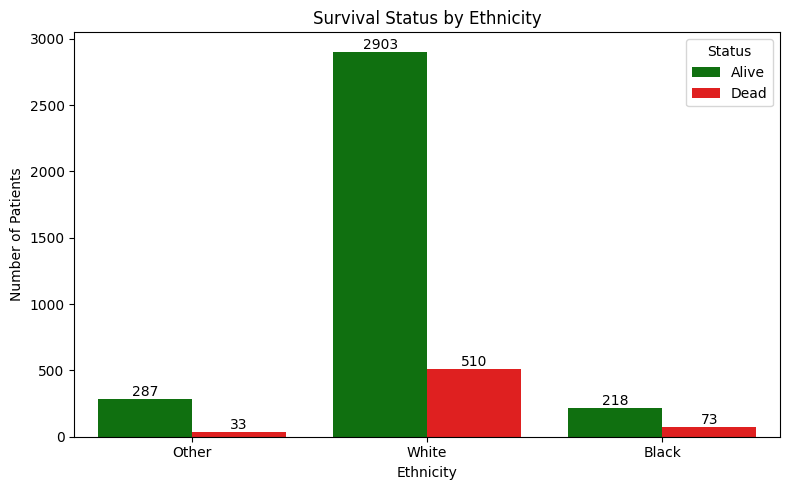

In [ ]:
df.columns = df.columns.str.strip()

print("Columns:", df.columns.tolist())

if df['Race'].dtype != object:
    race_mapping = {0: 'White', 1: 'Black', 2: 'Other'}
    df['Ethnicity'] = df['Race'].map(race_mapping)
else:
    df['Ethnicity'] = df['Race']

if df['Status'].dtype != object:
    df['Status'] = df['Status'].map({0: 'Alive', 1: 'Dead'})

df_plot = df.dropna(subset=['Ethnicity', 'Status'])

print("\nCheck Ethnicity & Status:")
print(df_plot[['Ethnicity', 'Status']].head())

plt.figure(figsize=(8,5))

ax = sns.countplot(
    x='Ethnicity',
    hue='Status',
    data=df_plot,
    palette={'Alive': 'green', 'Dead': 'red'}
)

plt.xlabel("Ethnicity")
plt.ylabel("Number of Patients")
plt.title("Survival Status by Ethnicity")

# Add count labels
for container in ax.containers:
    ax.bar_label(container, label_type='edge', fontsize=10)

plt.legend(title="Status")
plt.tight_layout()
plt.show()


In [ ]:
# Total cases per ethnicity
total_cases = df.groupby('Ethnicity').size()

alive_cases = df[df['Status'] == 'Alive'].groupby('Ethnicity').size()

survival_percentage = (alive_cases / total_cases) * 100

survival_df = survival_percentage.reset_index()
survival_df.columns = ['Ethnicity', 'Survival_Percentage']

survival_df


,Ethnicity,Survival_Percentage
0,Black,74.914089
1,Other,89.687500
2,White,85.057134


/tmp/ipython-input-3220479525.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


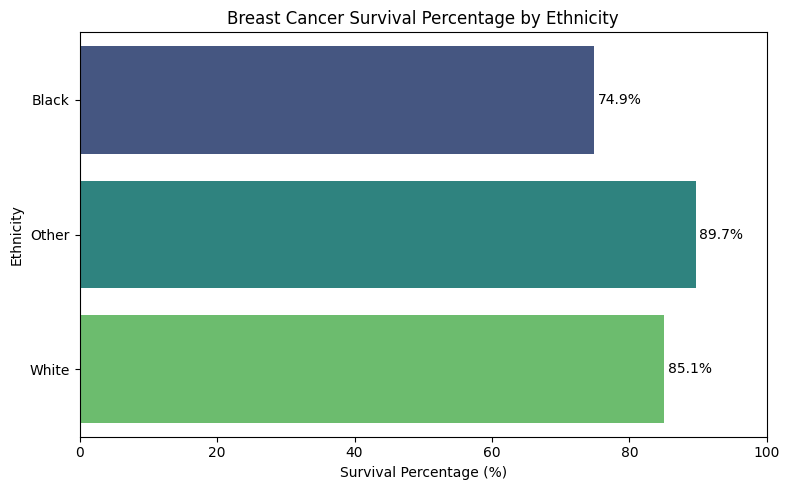

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Survival_Percentage',
    y='Ethnicity',
    data=survival_df,
    palette='viridis'
)

for index, value in enumerate(survival_df['Survival_Percentage']):
    plt.text(value + 0.5, index, f"{value:.1f}%", va='center')

plt.xlabel("Survival Percentage (%)")
plt.ylabel("Ethnicity")
plt.title("Breast Cancer Survival Percentage by Ethnicity")
plt.xlim(0, 100)
plt.tight_layout()
plt.show()


In [ ]:
avg_survival_by_ethnicity = df.groupby('Race')['Survival Months'].mean()

avg_survival_by_ethnicity


,Survival Months
Race,
Black,66.611684
Other,73.221875
White,71.517140


# **6th Stage Comparison**

The 6th Stage refers to the Derived AJCC 6th Edition Stage Group, which categorizes patients into Stages I–IV based on the combined assessment of tumor size, lymph node involvement, and distant metastasis.

Stage IIA – Small or medium tumor with limited spread to nearby lymph nodes.

Stage IIB – Larger tumor and/or greater lymph node involvement but still localized.

Stage IIIA – Cancer spread to multiple nearby lymph nodes indicating locally advanced disease.

Stage IIIB – Cancer has spread to the chest wall or skin of the breast.

Stage IIIC – Cancer spread to many regional lymph nodes including collarbone area.

The paitent in SEER Dataset only have Stage II and Stage III

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel("/content/SEER Breast Cancer Dataset  (1).xlsx")

df.columns = df.columns.str.strip()

df['Ethnicity'] = df['Race']

In [ ]:
import pandas as pd

df_stage = df[['Ethnicity', '6th Stage']].dropna()

stage_dist = (
    df_stage
    .groupby(['Ethnicity', '6th Stage'])
    .size()
    .reset_index(name='Count')
)

stage_dist['Percentage'] = (
    stage_dist
    .groupby('Ethnicity')['Count']
    .transform(lambda x: 100 * x / x.sum())
)

count_pivot = stage_dist.pivot(
    index='Ethnicity',
    columns='6th Stage',
    values='Count'
)

percent_pivot = stage_dist.pivot(
    index='Ethnicity',
    columns='6th Stage',
    values='Percentage'
)

final_table = count_pivot.copy()

for col in count_pivot.columns:
    final_table[col] = (
        count_pivot[col].astype(int).astype(str)
        + " ("
        + percent_pivot[col].round(1).astype(str)
        + "%)"
    )

final_table['Total Patients'] = count_pivot.sum(axis=1)

final_table

6th Stage,IIA,IIB,IIIA,IIIB,IIIC,Total Patients
Ethnicity,,,,,,
Black,91 (31.3%),81 (27.8%),69 (23.7%),6 (2.1%),44 (15.1%),291
Other,90 (28.1%),95 (29.7%),96 (30.0%),4 (1.2%),35 (10.9%),320
White,1124 (32.9%),954 (28.0%),885 (25.9%),57 (1.7%),393 (11.5%),3413


In [ ]:
pivot_pct = stage_dist.pivot(
    index='Ethnicity',
    columns='6th Stage',
    values='Percentage'
)

race_totals = (
    df_stage
    .groupby('Ethnicity')
    .size()
    .reset_index(name='Total Patients')
)


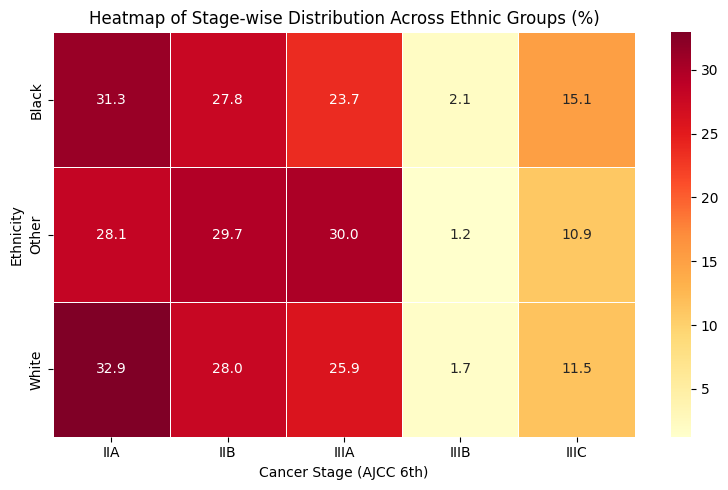

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.heatmap(
    pivot_pct,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    linewidths=0.5
)

plt.xlabel("Cancer Stage (AJCC 6th)")
plt.ylabel("Ethnicity")
plt.title("Heatmap of Stage-wise Distribution Across Ethnic Groups (%)")
plt.tight_layout()
plt.show()

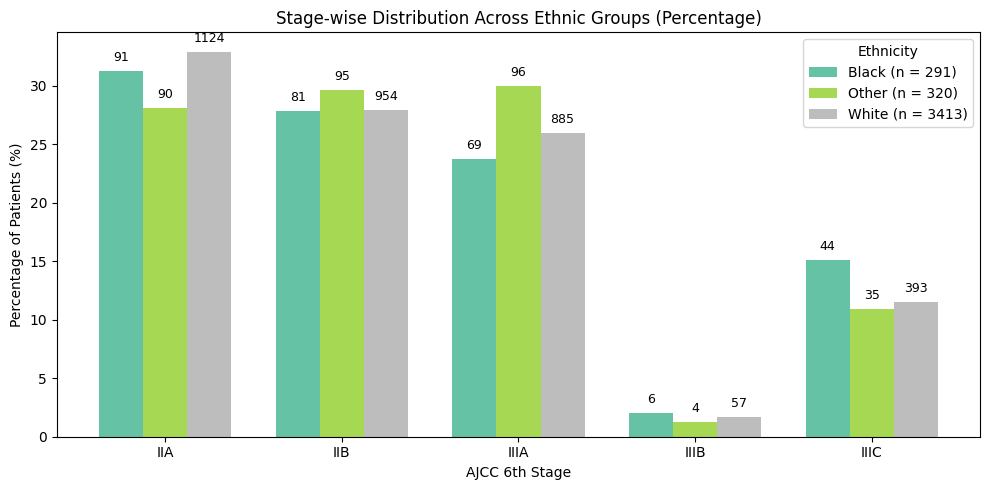

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

pct = stage_dist.pivot(index='6th Stage', columns='Ethnicity', values='Percentage')
cnt = stage_dist.pivot(index='6th Stage', columns='Ethnicity', values='Count')

stages = sorted(pct.index)
x = np.arange(len(stages))
w = 0.25

totals = df_stage['Ethnicity'].value_counts()

plt.figure(figsize=(10,5))

b1 = plt.bar(x - w, pct['Black'], w, color='#66c2a5',
             label=f"Black (n = {totals['Black']})")
b2 = plt.bar(x, pct['Other'], w, color='#a6d854',
             label=f"Other (n = {totals['Other']})")
b3 = plt.bar(x + w, pct['White'], w, color='#bdbdbd',
             label=f"White (n = {totals['White']})")

for bars, counts in zip([b1, b2, b3],
                         [cnt['Black'], cnt['Other'], cnt['White']]):
    for bar, c in zip(bars, counts):
        plt.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.6,
                 int(c),
                 ha='center', va='bottom', fontsize=9)

plt.xlabel("AJCC 6th Stage")
plt.ylabel("Percentage of Patients (%)")
plt.title("Stage-wise Distribution Across Ethnic Groups (Percentage)")
plt.xticks(x, stages)
plt.legend(title="Ethnicity")
plt.tight_layout()
plt.show()


/tmp/ipython-input-1343253489.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  black_df.groupby("Tumor_Size_Group")["Status"]


<Figure size 800x500 with 0 Axes>

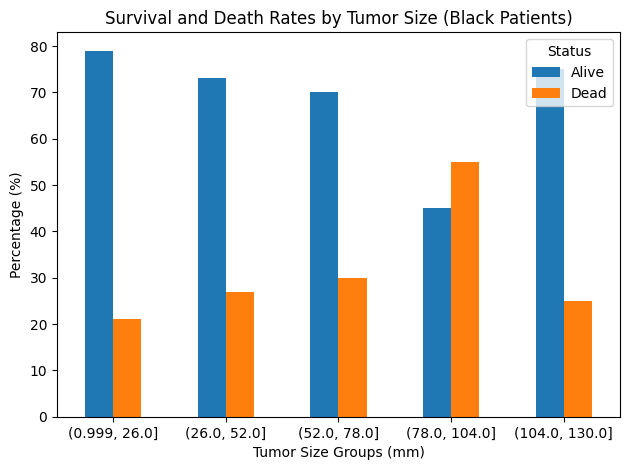

Status,Alive,Dead
Tumor_Size_Group,,
"(0.999, 26.0]",79,21
"(26.0, 52.0]",73,27
"(52.0, 78.0]",70,30
"(78.0, 104.0]",45,55
"(104.0, 130.0]",75,25


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_excel("/content/SEER Breast Cancer Dataset  (1).xlsx")

df.rename(columns={"Race ": "Race"}, inplace=True)

black_df = df[df["Race"] == "Black"].copy()

black_df = black_df[black_df["Tumor Size"] >= 1]

min_size = int(black_df["Tumor Size"].min())
max_size = int(black_df["Tumor Size"].max())
bins = np.linspace(min_size, max_size, 6).astype(int)

black_df["Tumor_Size_Group"] = pd.cut(
    black_df["Tumor Size"],
    bins=bins,
    include_lowest=True
)

rate_table = (
    black_df.groupby("Tumor_Size_Group")["Status"]
    .value_counts(normalize=True)
    .unstack()
    .fillna(0)
    .mul(100)
    .round(0)
    .astype(int)
)

plt.figure(figsize=(8,5))
rate_table.plot(kind="bar")
plt.xlabel("Tumor Size Groups (mm)")
plt.ylabel("Percentage (%)")
plt.title("Survival and Death Rates by Tumor Size (Black Patients)")
plt.xticks(rotation=0)
plt.legend(title="Status")
plt.tight_layout()
plt.show()

rate_table


<Figure size 800x500 with 0 Axes>

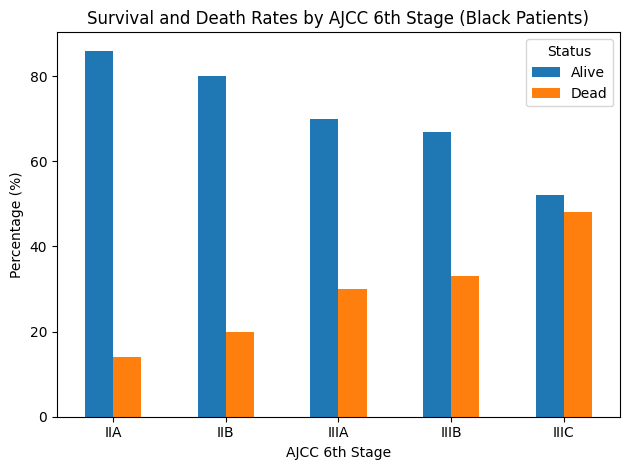

Status,Alive,Dead
6th Stage,,
IIA,86%,14%
IIB,80%,20%
IIIA,70%,30%
IIIB,67%,33%
IIIC,52%,48%


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel("/content/SEER Breast Cancer Dataset  (1).xlsx")

df.rename(columns={"Race ": "Race"}, inplace=True)

black_df = df[df["Race"] == "Black"].copy()

black_df = black_df[black_df["6th Stage"].notna()]
black_df = black_df[black_df["6th Stage"] != "Unknown"]

stage_rate = (
    black_df.groupby("6th Stage")["Status"]
    .value_counts(normalize=True)
    .unstack()
    .fillna(0)
    .mul(100)
    .round(0)
    .astype(int)
)

stage_order = sorted(stage_rate.index)
stage_rate = stage_rate.loc[stage_order]

plt.figure(figsize=(8,5))
stage_rate.plot(kind="bar")
plt.xlabel("AJCC 6th Stage")
plt.ylabel("Percentage (%)")
plt.title("Survival and Death Rates by AJCC 6th Stage (Black Patients)")
plt.xticks(rotation=0)
plt.legend(title="Status")
plt.tight_layout()
plt.show()

stage_rate_display = stage_rate.astype(str) + "%"

stage_rate_display



In [ ]:
stage_counts = (
    black_df
    .groupby("6th Stage")["Status"]
    .value_counts()
    .unstack()
    .fillna(0)
)

stage_counts["Total"] = stage_counts.sum(axis=1)

stage_counts["Death_Percentage"] = (
    stage_counts["Dead"] / stage_counts["Total"] * 100
).round(1)

stage_counts


Status,Alive,Dead,Total,Death_Percentage
6th Stage,,,,
IIA,78,13,91,14.3
IIB,65,16,81,19.8
IIIA,48,21,69,30.4
IIIB,4,2,6,33.3
IIIC,23,21,44,47.7


In [ ]:
min_n = 10
stage_filtered = stage_counts[stage_counts["Total"] >= min_n]

stage_filtered


Status,Alive,Dead,Total,Death_Percentage
6th Stage,,,,
IIA,78,13,91,14.3
IIB,65,16,81,19.8
IIIA,48,21,69,30.4
IIIC,23,21,44,47.7


In [ ]:
most_dangerous_stage = stage_filtered.sort_values(
    by="Death_Percentage",
    ascending=False
).head(1)

most_dangerous_stage

Status,Alive,Dead,Total,Death_Percentage
6th Stage,,,,
IIIC,23,21,44,47.7


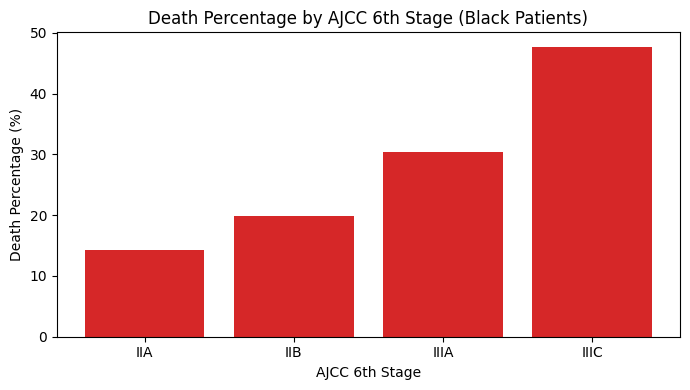

In [ ]:
plt.figure(figsize=(7,4))

plt.bar(
    stage_filtered.index,
    stage_filtered["Death_Percentage"],
    color="#d62728"
)

plt.ylabel("Death Percentage (%)")
plt.xlabel("AJCC 6th Stage")
plt.title("Death Percentage by AJCC 6th Stage (Black Patients)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_excel("/content/SEER Breast Cancer Dataset  (1).xlsx")

df.rename(columns={"Race ": "Race"}, inplace=True)

black_df = df[df["Race"] == "Black"].copy()

black_df = black_df[black_df["Tumor Size"] >= 1]

black_df = black_df[black_df["6th Stage"].notna()]
black_df = black_df[black_df["6th Stage"] != "Unknown"]

bins = [1, 26, 52, 78, 104, 130]

black_df["Tumor_Size_Group"] = pd.cut(
    black_df["Tumor Size"],
    bins=bins,
    include_lowest=True
)

count_table = (
    black_df
    .groupby(["6th Stage", "Tumor_Size_Group", "Status"])
    .size()
    .unstack(fill_value=0)
)

count_table


/tmp/ipython-input-3793813912.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["6th Stage", "Tumor_Size_Group", "Status"])


Status                      Alive  Dead
6th Stage Tumor_Size_Group             
IIA       (0.999, 26.0]        78    13
          (26.0, 52.0]          0     0
          (52.0, 78.0]          0     0
          (78.0, 104.0]         0     0
          (104.0, 130.0]        0     0
IIB       (0.999, 26.0]        20     7
          (26.0, 52.0]         45     9
          (52.0, 78.0]          0     0
          (78.0, 104.0]         0     0
          (104.0, 130.0]        0     0
IIIA      (0.999, 26.0]        20     6
          (26.0, 52.0]         17    10
          (52.0, 78.0]          6     3
          (78.0, 104.0]         4     2
          (104.0, 130.0]        1     0
IIIB      (0.999, 26.0]         0     1
          (26.0, 52.0]          1     0
          (52.0, 78.0]          2     0
          (78.0, 104.0]         0     1
          (104.0, 130.0]        1     0
IIIC      (0.999, 26.0]         8     7
          (26.0, 52.0]          7     7
          (52.0, 78.0]          6     3
          (78.0, 104.0]         1     3
          (104.0, 130.0]        1     1

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_excel("/content/SEER Breast Cancer Dataset  (1).xlsx")

df.rename(columns={"Race ": "Race"}, inplace=True)

black_df = df[df["Race"] == "Black"].copy()

black_df = black_df[black_df["Tumor Size"] >= 1]

black_df = black_df[black_df["6th Stage"].notna()]
black_df = black_df[black_df["6th Stage"] != "Unknown"]

bins = [1, 26, 52, 78, 104, 130]
black_df["Tumor_Size_Group"] = pd.cut(
    black_df["Tumor Size"],
    bins=bins,
    include_lowest=True
)

count_table = (
    black_df
    .groupby(["6th Stage", "Tumor_Size_Group", "Status"])
    .size()
    .unstack(fill_value=0)
)

count_table["Total"] = count_table["Alive"] + count_table["Dead"]

count_table = count_table[count_table["Total"] >= 1]

percent_table = (
    count_table[["Alive", "Dead"]]
    .div(count_table["Total"], axis=0)
    .mul(100)
    .round(0)
)

percent_table


/tmp/ipython-input-2547111558.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["6th Stage", "Tumor_Size_Group", "Status"])


Status                      Alive   Dead
6th Stage Tumor_Size_Group              
IIA       (0.999, 26.0]      86.0   14.0
IIB       (0.999, 26.0]      74.0   26.0
          (26.0, 52.0]       83.0   17.0
IIIA      (0.999, 26.0]      77.0   23.0
          (26.0, 52.0]       63.0   37.0
          (52.0, 78.0]       67.0   33.0
          (78.0, 104.0]      67.0   33.0
          (104.0, 130.0]    100.0    0.0
IIIB      (0.999, 26.0]       0.0  100.0
          (26.0, 52.0]      100.0    0.0
          (52.0, 78.0]      100.0    0.0
          (78.0, 104.0]       0.0  100.0
          (104.0, 130.0]    100.0    0.0
IIIC      (0.999, 26.0]      53.0   47.0
          (26.0, 52.0]       50.0   50.0
          (52.0, 78.0]       67.0   33.0
          (78.0, 104.0]      25.0   75.0
          (104.0, 130.0]     50.0   50.0

## **ETHNICITY COMPARISON**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_excel("/content/SEER Breast Cancer Dataset  (1).xlsx")


df.rename(columns={"Race ": "Race"}, inplace=True)

df = df[df["Tumor Size"] >= 1]

df = df[df["6th Stage"].notna()]
df = df[df["6th Stage"] != "Unknown"]

df = df[df["Race"].isin(["Black", "White", "Other"])]


In [ ]:
min_size = int(df["Tumor Size"].min())
max_size = int(df["Tumor Size"].max())

bins = np.linspace(min_size, max_size, 6).astype(int)

df["Tumor_Size_Group"] = pd.cut(
    df["Tumor Size"],
    bins=bins,
    include_lowest=True
)


In [ ]:
survival_pct = (
    df
    .groupby(["6th Stage", "Tumor_Size_Group", "Race"])["Status"]
    .value_counts(normalize=True)
    .unstack()
    .fillna(0)
    .mul(100)
    .round(0)
    .astype(int)
)

survival_pct


/tmp/ipython-input-3326009605.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["6th Stage", "Tumor_Size_Group", "Race"])["Status"]


Status                            Alive  Dead
6th Stage Tumor_Size_Group Race              
IIA       (0.999, 28.0]    Black     86    14
                           Other     96     4
                           White     93     7
          (28.0, 56.0]     Black      0     0
                           Other      0     0
...                                 ...   ...
IIIC      (84.0, 112.0]    Other    100     0
                           White     58    42
          (112.0, 140.0]   Black     50    50
                           Other      0     0
                           White     17    83

[75 rows x 2 columns]

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_excel("/content/SEER Breast Cancer Dataset  (1).xlsx")
df.rename(columns={"Race ": "Race"}, inplace=True)

df = df[df["Tumor Size"] >= 1]
df = df[df["6th Stage"].notna()]
df = df[df["6th Stage"] != "Unknown"]
df = df[df["Race"].isin(["Black", "White", "Other"])]

bins = np.linspace(df["Tumor Size"].min(), df["Tumor Size"].max(), 6).astype(int)
df["Tumor_Size_Group"] = pd.cut(df["Tumor Size"], bins=bins, include_lowest=True)

survival_pct = (
    df.groupby(["6th Stage", "Tumor_Size_Group", "Race"])["Status"]
      .value_counts(normalize=True)
      .unstack()
      .fillna(0)
      .mul(100)
      .round(0)
)

counts = (
    df.groupby(["6th Stage", "Tumor_Size_Group", "Race"])["Status"]
      .count()
)

valid_idx = counts[counts >= 5].index
survival_pct = survival_pct.loc[survival_pct.index.isin(valid_idx)]

survival_pct


/tmp/ipython-input-3842027525.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["6th Stage", "Tumor_Size_Group", "Race"])["Status"]
/tmp/ipython-input-3842027525.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["6th Stage", "Tumor_Size_Group", "Race"])["Status"]


Status                            Alive  Dead
6th Stage Tumor_Size_Group Race              
IIA       (0.999, 28.0]    Black   86.0  14.0
                           Other   96.0   4.0
                           White   93.0   7.0
IIB       (0.999, 28.0]    Black   79.0  21.0
                           Other   88.0  12.0
                           White   90.0  10.0
          (28.0, 56.0]     Black   81.0  19.0
                           Other   93.0   7.0
                           White   87.0  13.0
IIIA      (0.999, 28.0]    Black   75.0  25.0
                           Other   89.0  11.0
                           White   83.0  17.0
          (28.0, 56.0]     Black   63.0  37.0
                           Other   94.0   6.0
                           White   81.0  19.0
          (56.0, 84.0]     Black   70.0  30.0
                           Other   83.0  17.0
                           White   86.0  14.0
          (84.0, 112.0]    Other   75.0  25.0
                           White   79.0  21.0
          (112.0, 140.0]   White   87.0  13.0
IIIB      (0.999, 28.0]    White   71.0  29.0
          (28.0, 56.0]     White   76.0  24.0
          (56.0, 84.0]     White   58.0  42.0
          (84.0, 112.0]    White   71.0  29.0
IIIC      (0.999, 28.0]    Black   47.0  53.0
                           Other   82.0  18.0
                           White   63.0  37.0
          (28.0, 56.0]     Black   64.0  36.0
                           Other   74.0  26.0
                           White   63.0  37.0
          (56.0, 84.0]     Black   50.0  50.0
                           White   59.0  41.0
          (84.0, 112.0]    White   58.0  42.0
          (112.0, 140.0]   White   17.0  83.0

/tmp/ipython-input-2683497223.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["Tumor_Size_Group", "Race"])["Status"]
/tmp/ipython-input-2683497223.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["Tumor_Size_Group", "Race"])["Status"]


<Figure size 900x500 with 0 Axes>

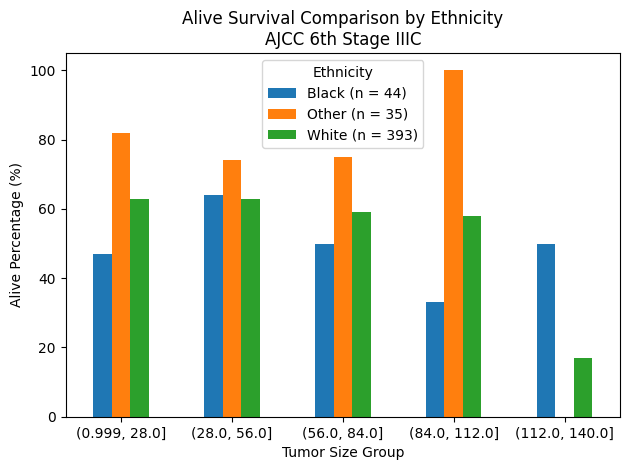

Status                  Alive  Dead
Tumor_Size_Group Race              
(0.999, 28.0]    Black   47.0  53.0
                 Other   82.0  18.0
                 White   63.0  37.0
(28.0, 56.0]     Black   64.0  36.0
                 Other   74.0  26.0
                 White   63.0  37.0
(56.0, 84.0]     Black   50.0  50.0
                 Other   75.0  25.0
                 White   59.0  41.0
(84.0, 112.0]    Black   33.0  67.0
                 Other  100.0   0.0
                 White   58.0  42.0
(112.0, 140.0]   Black   50.0  50.0
                 White   17.0  83.0

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_excel("/content/SEER Breast Cancer Dataset  (1).xlsx")

df.rename(columns={"Race ": "Race"}, inplace=True)

df = df[df["Tumor Size"] >= 1]
df = df[df["6th Stage"].notna()]
df = df[df["6th Stage"] != "Unknown"]
df = df[df["Race"].isin(["Black", "White", "Other"])]

bins = np.linspace(df["Tumor Size"].min(), df["Tumor Size"].max(), 6).astype(int)
df["Tumor_Size_Group"] = pd.cut(df["Tumor Size"], bins=bins, include_lowest=True)


stage = "IIIC"
stage_df = df[df["6th Stage"] == stage]


stage_pct = (
    stage_df
    .groupby(["Tumor_Size_Group", "Race"])["Status"]
    .value_counts(normalize=True)
    .unstack()
    .fillna(0)
    .mul(100)
    .round(0)
)


stage_counts = (
    stage_df
    .groupby(["Tumor_Size_Group", "Race"])["Status"]
    .count()
)

valid_idx = stage_counts[stage_counts >= 1].index
stage_pct = stage_pct.loc[stage_pct.index.isin(valid_idx)]

race_totals = (
    stage_df.groupby("Race")["Status"]
            .count()
            .to_dict()
)

alive_data = stage_pct["Alive"].unstack()

plt.figure(figsize=(9,5))
alive_data.plot(kind="bar")

plt.ylabel("Alive Percentage (%)")
plt.xlabel("Tumor Size Group")
plt.title("Alive Survival Comparison by Ethnicity\nAJCC 6th Stage IIIC")
plt.xticks(rotation=0)

handles, labels = plt.gca().get_legend_handles_labels()
new_labels = [f"{race} (n = {race_totals.get(race, 0)})" for race in labels]
plt.legend(handles, new_labels, title="Ethnicity")

plt.tight_layout()
plt.show()

stage_pct


# **Odd of Death**

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_excel("/content/SEER Breast Cancer Dataset  (1).xlsx")
df.columns = df.columns.str.strip()

stage_df = df[["Race", "6th Stage", "Status"]].dropna()

stage_df = stage_df[stage_df["6th Stage"] != "Unknown"]

stage_df["event"] = stage_df["Status"].apply(lambda x: 1 if x == "Dead" else 0)

counts = (
    stage_df
    .groupby(["6th Stage", "Race"])["event"]
    .agg(["sum", "count"])
    .reset_index()
)

# Calculate odds = deaths / alive
counts["alive"] = counts["count"] - counts["sum"]
counts["odds"] = counts["sum"] / counts["alive"]

odds_table = counts.pivot(
    index="6th Stage",
    columns="Race",
    values="odds"
)

# Round for readability
odds_table = odds_table.round(2)

print("\nStage-wise Odds Ratio Table:\n")
print(odds_table)



Stage-wise Odds Ratio Table:

Race       Black  Other  White
6th Stage                     
IIA         0.17   0.05   0.08
IIB         0.25   0.10   0.13
IIIA        0.44   0.13   0.21
IIIB        0.50   0.33   0.42
IIIC        0.91   0.30   0.63


In [ ]:
import pandas as pd
import numpy as np

df = pd.read_excel("/content/SEER Breast Cancer Dataset  (1).xlsx")
df.columns = df.columns.str.strip()

size_df = df[["Race", "Tumor Size", "Status"]].dropna()

size_df = size_df[size_df["Tumor Size"] > 0]

size_df["event"] = size_df["Status"].apply(lambda x: 1 if x == "Dead" else 0)

min_size = int(size_df["Tumor Size"].min())
max_size = int(size_df["Tumor Size"].max())
bins = np.linspace(min_size, max_size, 6).astype(int)

size_df["Tumor_Size_Group"] = pd.cut(
    size_df["Tumor Size"],
    bins=bins,
    include_lowest=True
)

counts = (
    size_df
    .groupby(["Tumor_Size_Group", "Race"])["event"]
    .agg(["sum", "count"])
    .reset_index()
)

counts["alive"] = counts["count"] - counts["sum"]
counts["odds"] = counts["sum"] / counts["alive"]

odds_table_size = counts.pivot(
    index="Tumor_Size_Group",
    columns="Race",
    values="odds"
)

odds_table_size = odds_table_size.round(2)

print("\nTumor-size-wise Odds Table:\n")
print(odds_table_size)



Tumor-size-wise Odds Table:

Race              Black  Other  White
Tumor_Size_Group                     
(0.999, 28.0]      0.28   0.09   0.13
(28.0, 56.0]       0.36   0.11   0.23
(56.0, 84.0]       0.54   0.26   0.28
(84.0, 112.0]      1.33   0.29   0.40
(112.0, 140.0]     0.33   0.00   0.47


/tmp/ipython-input-667573231.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["Tumor_Size_Group", "Race"])["event"]


# **Kaplan–Meier Curves by Ethnicity + Log-rank Test**
The Kaplan-Meier curve visualizes survival probabilities over time, while the log-rank test statistically compares two or more of these curves to see if there's a significant difference in survival between groups

In [ ]:
!pip install lifelines


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 350.0/350.0 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 4.5 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=662dee8d9b297fe566ce2f5a7dc36bad333330d2a1ef7c5ddab0e29902b6f472
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


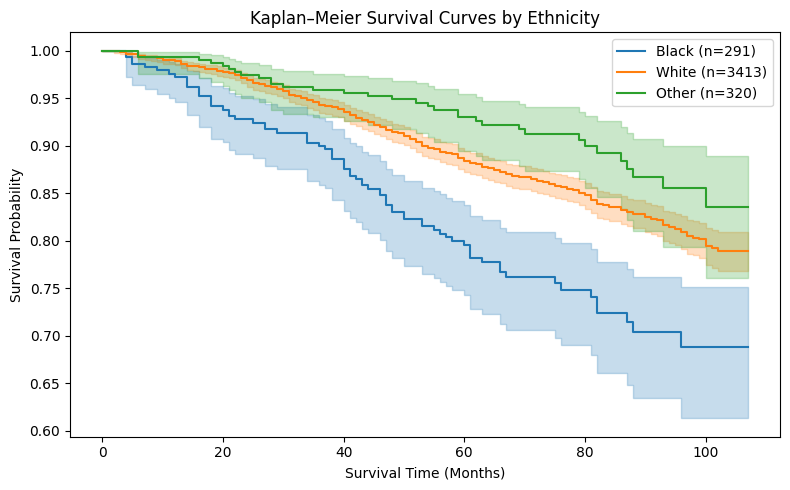


Log-rank Test Result:
<lifelines.StatisticalResult: multivariate_logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 2
         test_name = multivariate_logrank_test

---
 test_statistic      p  -log2(p)
          30.98 <0.005     22.35


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
from lifelines.statistics import multivariate_logrank_test

df = pd.read_excel("/content/SEER Breast Cancer Dataset  (1).xlsx")
df.columns = df.columns.str.strip()

km_df = df[["Race", "Survival Months", "Status"]].dropna()

km_df["event"] = km_df["Status"].apply(lambda x: 1 if x == "Dead" else 0)

plt.figure(figsize=(8,5))

kmf = KaplanMeierFitter()

for race in ["Black", "White", "Other"]:
    race_df = km_df[km_df["Race"] == race]

    kmf.fit(
        durations=race_df["Survival Months"],
        event_observed=race_df["event"],
        label=f"{race} (n={len(race_df)})"
    )

    kmf.plot_survival_function()

plt.title("Kaplan–Meier Survival Curves by Ethnicity")
plt.xlabel("Survival Time (Months)")
plt.ylabel("Survival Probability")
plt.tight_layout()
plt.show()

results = multivariate_logrank_test(
    km_df["Survival Months"],
    km_df["Race"],
    km_df["event"]
)

print("\nLog-rank Test Result:")
print(results)


In [ ]:
print("\nLog-rank Test Result:")
print(f"Chi-square = {results.test_statistic:.2f}")
print(f"p-value = {results.p_value:.8f}")



Log-rank Test Result:
Chi-square = 30.98
p-value = 0.00000019
